In [1]:
pip install -r requirements.txt


   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
x = pd.read_csv('../data/raw/TCGA-PANCAN-HiSeq-801x20531/data.csv', index_col=0)

y = pd.read_csv('../data/raw/TCGA-PANCAN-HiSeq-801x20531/labels.csv', index_col=0)
y = y.squeeze()

print(x.shape)
print(y.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/TCGA-PANCAN-HiSeq-801x20531/data.csv'

In [ ]:
print(f"Total missing values: {x.isnull().sum().sum()}")
print(f"Duplicate rows: {x.duplicated().sum()}")

Total missing values: 0
Duplicate rows: 0


In [ ]:
x.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [ ]:
x.dtypes.value_counts()

float64    20531
Name: count, dtype: int64

x contains 20,531 gene values labelled from gene_0 to gene_20530.

Values are continuous floats (that have been normalised by TCGA) note they are not not raw integer read counts.

In [ ]:
y.head()

sample_0    PRAD
sample_1    LUAD
sample_2    PRAD
sample_3    PRAD
sample_4    BRCA
Name: Class, dtype: object

In [ ]:
print(y.value_counts())

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


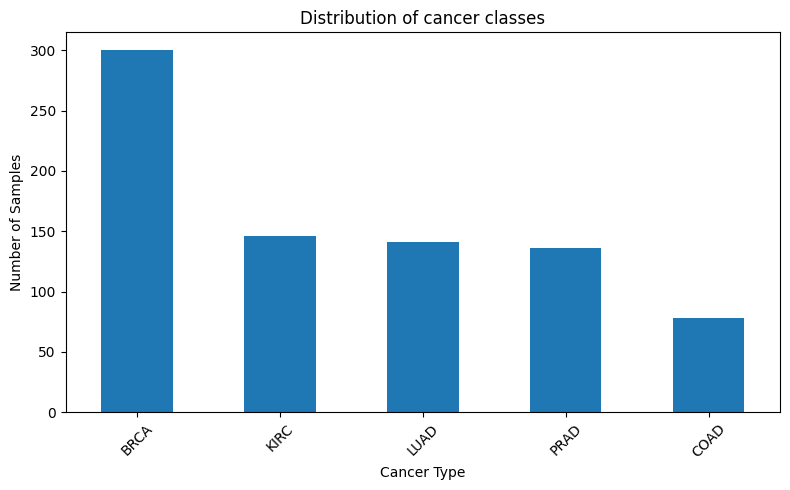

In [ ]:
y.value_counts().plot(kind='bar', figsize=(8, 5))

plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.title("Distribution of cancer classes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

There exist 5 cancer classes mapped as:
1. BRCA (breast)
2. KIRC (kidney)
3. COAD (colon)
4. LUAD (lung)
5. PRAD (prostate)

Note the skew towards breast cancer and how little colon cancer samples are present. A stratified sampling approach evaluated with macro F1 must be used to deal with this bias over plain accuracy.

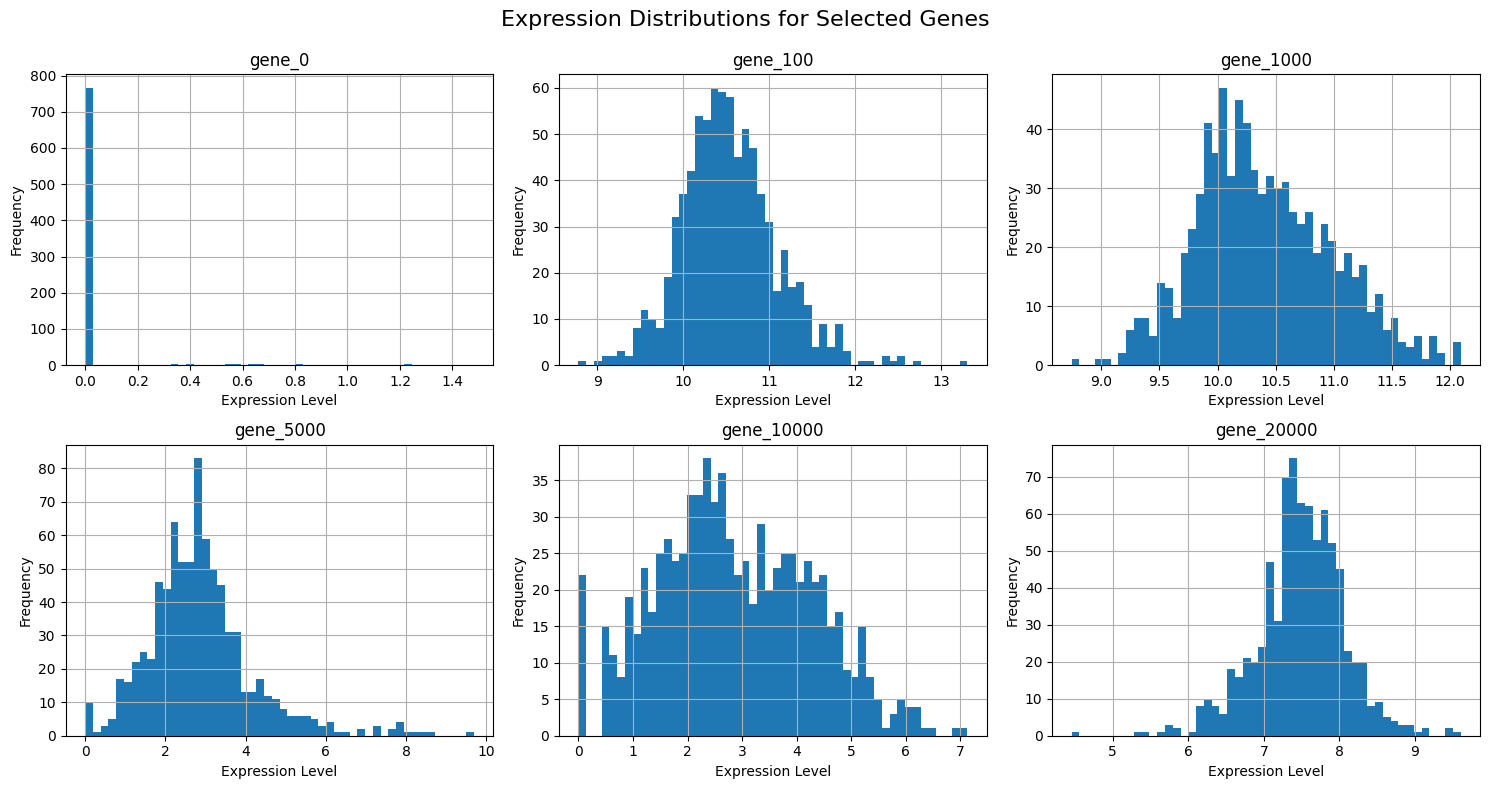

In [ ]:
selected_genes = x.columns[[0, 100, 1000, 5000, 10000, 20000]]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for gene, ax in zip(selected_genes, axes):
    x[gene].hist(bins=50, ax=ax)
    ax.set_title(gene)
    ax.set_xlabel("Expression Level")
    ax.set_ylabel("Frequency")

fig.suptitle("Expression Distributions for Selected Genes", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.savefig('../outputs/figures/normalised_value_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

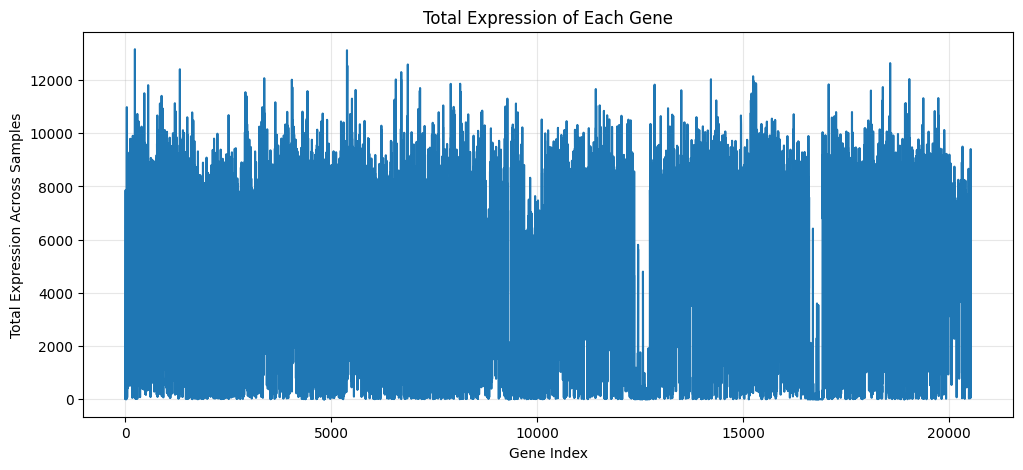

In [ ]:
gene_sums = x.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(gene_sums.values)
plt.xlabel("Gene Index")
plt.ylabel("Total Expression Across Samples")
plt.title("Total Expression of Each Gene")
plt.grid(alpha=0.3)
plt.show()

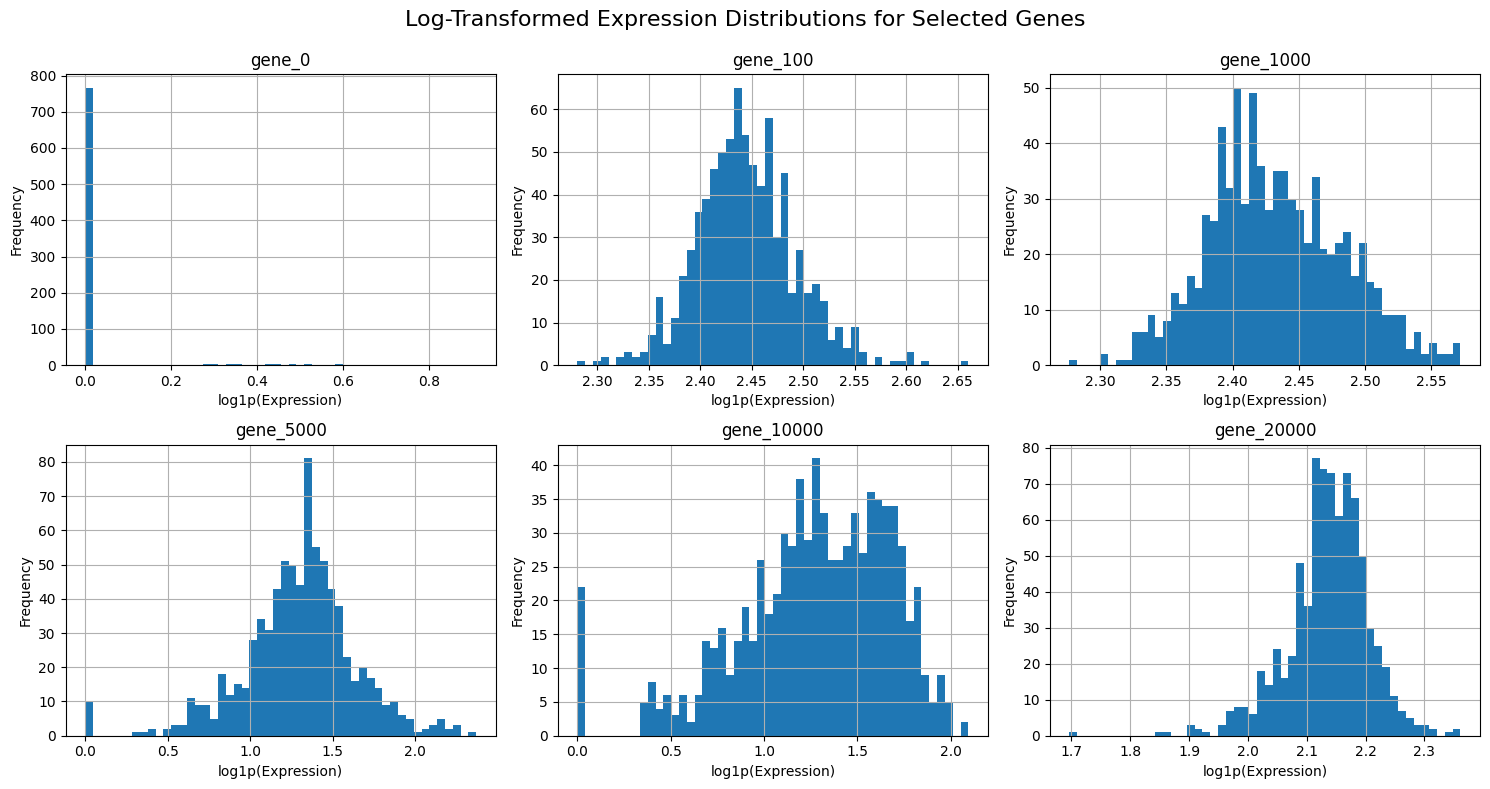

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for gene, ax in zip(selected_genes, axes):
    np.log1p(x[gene]).hist(bins=50, ax=ax)
    ax.set_title(gene)
    ax.set_xlabel("log1p(Expression)")
    ax.set_ylabel("Frequency")

fig.suptitle("Log-Transformed Expression Distributions for Selected Genes", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [ ]:
summary = x.describe().T
print(summary[['mean', '50%', 'std', 'min', 'max']])

sparsity = (x == 0).sum().sum() / (x.shape[0] * x.shape[1]) * 100
print(sparsity)

                 mean        50%       std       min        max
gene_0       0.026642   0.000000  0.136850  0.000000   1.482332
gene_1       3.010909   3.143687  1.200828  0.000000   6.237034
gene_2       3.095350   3.127006  1.065601  0.000000   6.063484
gene_3       6.722305   6.655893  0.638819  5.009284  10.129528
gene_4       9.813612   9.791599  0.506537  8.435999  11.355621
...               ...        ...       ...       ...        ...
gene_20526  11.742228  11.749802  0.670371  9.045255  13.715361
gene_20527  10.155271  10.191207  0.580569  7.530141  11.675653
gene_20528   9.590726   9.566511  0.563849  7.864533  12.813320
gene_20529   5.528177   5.218618  2.073859  0.593975  11.205836
gene_20530   0.095411   0.000000  0.364529  0.000000   5.254133

[20531 rows x 5 columns]
14.21755512248431


Mean is far higher than the median meaning the data has a right skew. So some genes have high values and dominate the gene values and others are mostly just 0s.

Note also that the column names have been anonoymised to gene_X so the original TCGA gene symbol mapping will need to be obtained and resolved to determine which genes are the transcription factors that order the other genes.

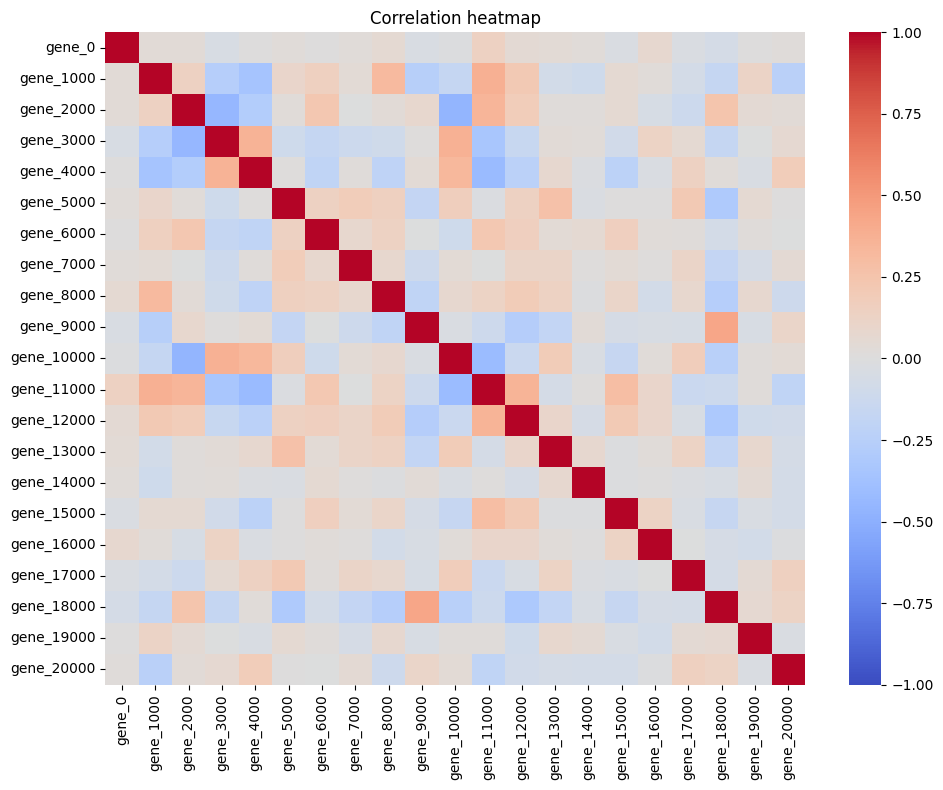

In [ ]:
sample_genes = x.columns[::1000]
corr_matrix = x[sample_genes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap_sample.png', dpi=150, bbox_inches='tight')
plt.show()

There is some level of correlation (both positive and negative) between different genes indicating how they are interlinked.

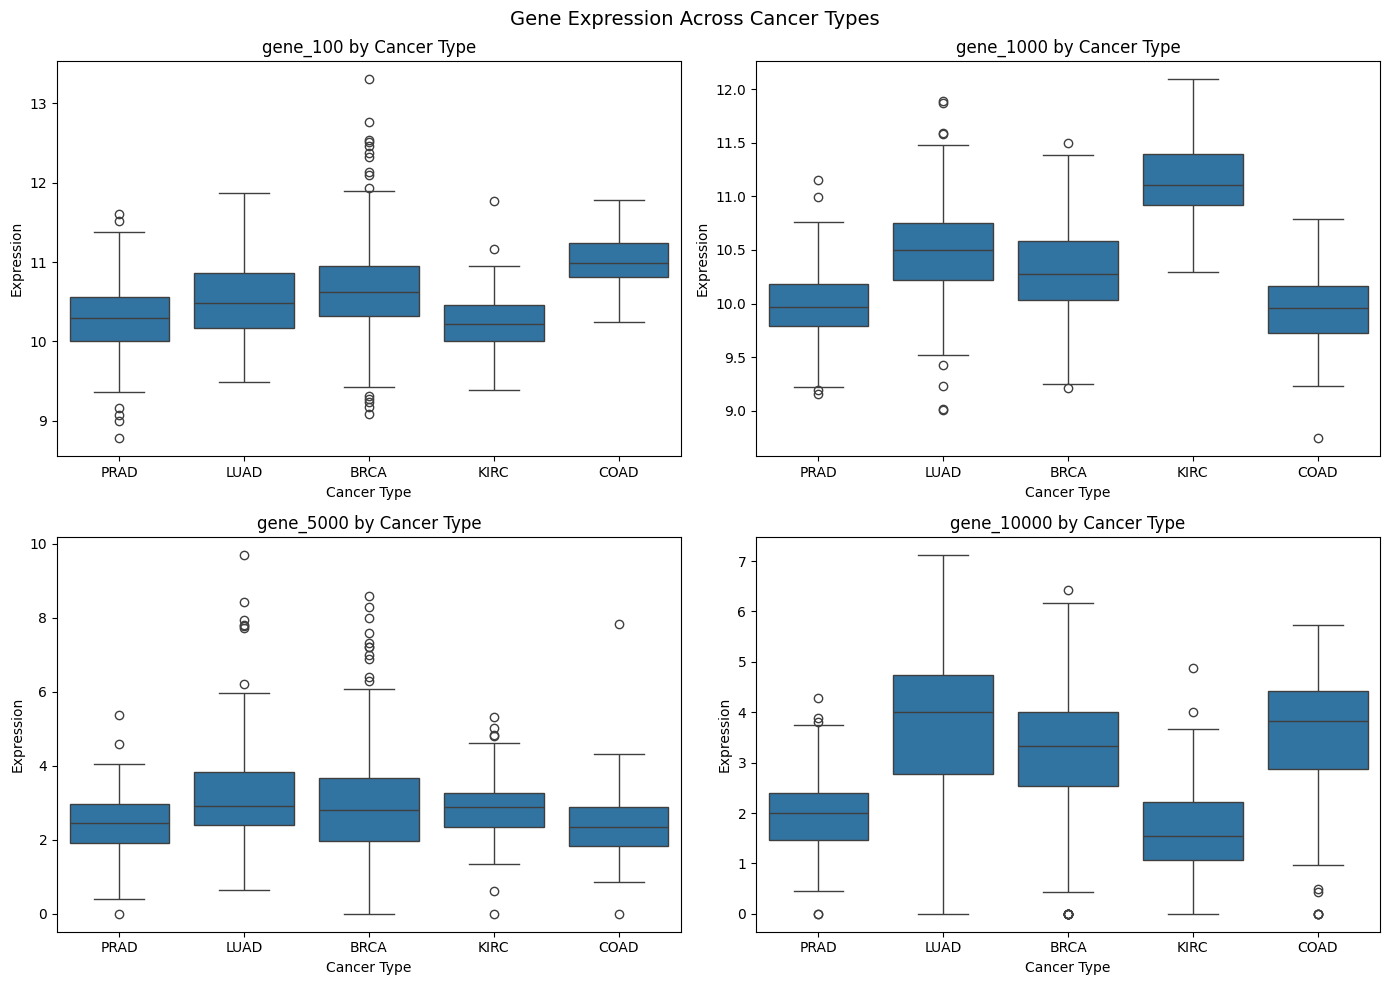

In [ ]:
sample_genes = x.columns[[100, 1000, 5000, 10000]]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for gene, ax in zip(sample_genes, axes):
    data = pd.DataFrame({'Expression': x[gene], 'Cancer Type': y})
    sns.boxplot(data=data, x='Cancer Type', y='Expression', ax=ax)
    ax.set_title(f'{gene} by Cancer Type')

fig.suptitle('Gene Expression Across Cancer Types', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/expression_by_cancer_type.png', dpi=150, bbox_inches='tight')
plt.show()


### EDA Summmary

- 801 samples × 20,531 genes with no missing values and no duplicates clean to work with.
- All features are float64 since data has been pre-processed by TCGA (normalised instead of raw int values).
- There is a class imbalance since BRCA 300 vs COAD 78 is smallest meaning that stratified sampling required.
- Expression distributions show right skew with 14% sparsity and further investigation needed on whether additional log transformation is appropriate given pre-processing.
- Gene columns are anonymised so identification of transcription factors will have to be found elsehow.